In [ ]:
pip install kaggle

In [ ]:
import shutil
import os

source_path = "/Users/imtiazislam/.cache/kagglehub/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/versions/1"
destination_path = "data"  # this will create a folder in your notebook directory

# Copy entire dataset folder
shutil.copytree(source_path, destination_path, dirs_exist_ok=True)

print("Dataset copied to:", os.path.abspath(destination_path))

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
## The dataset consists of X transactions with all numerical features, making it suitable for machine learning-based anomaly detection.

In [13]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [15]:
import seaborn as sns 

In [17]:
import matplotlib.pyplot as plt

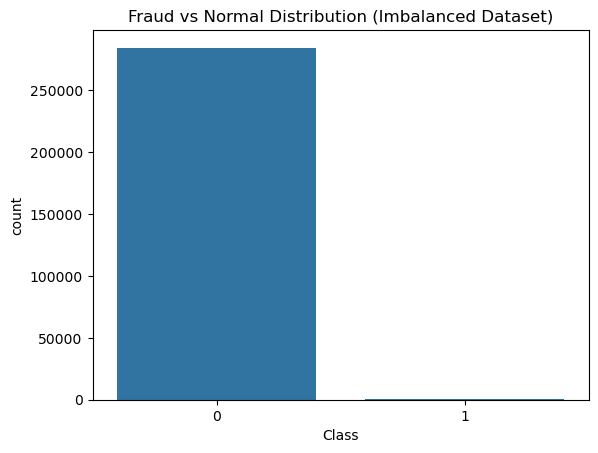

In [19]:
sns.countplot(x = 'Class', data=df) 
plt.title("Fraud vs Normal Distribution (Imbalanced Dataset)") 
plt.show()

In [21]:
#The dataset is highly imbalanced, with fraudulent transactions representing approximately 0.17% of total transactions. 
#This extreme imbalance makes anomaly detection techniques particularly suitable for identifying rare fraudulent behavior.

In [23]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [25]:
# Scale Amount

In [27]:
from sklearn.preprocessing import StandardScaler

In [29]:
df['Amount']=StandardScaler().fit_transform(df[['Amount']])

In [31]:
df = df.drop(columns = ['Time'])

In [201]:
# Prep DATA for Anomaly Detection

In [45]:
from sklearn.model_selection import train_test_split

In [47]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [55]:
# We don’t know fraud beforehand—we only learn normal behavior

In [57]:
print("Train shape:", X_train.shape)
print("Test shape:",X_test.shape)

Train shape: (227845, 29)
Test shape: (56962, 29)


In [59]:
                                   # Isolation Forest (Anomaly Detection)

In [61]:
#Isolation Forest:
#Learns normal patterns
#Flags anything “hard to fit” as anomaly (fraud)

In [63]:
from sklearn.ensemble import IsolationForest
# contamination = expected fraud rate (~0.17%)
model_if = IsolationForest(
    contamination = 0.01,
    random_state=42
)
model_if.fit(X_train)


,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [203]:
# predict on test data

In [69]:
preds_if_final = model_if.predict(X_test)

In [71]:
preds_if_final = [1 if x == -1 else 0 for x in preds_if_final]

In [73]:
# Evaluate Model

In [75]:
from sklearn.metrics import classification_report
print (classification_report(y_test, preds_if_final))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.65      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.82      0.59     56962
weighted avg       1.00      0.99      0.99     56962



In [77]:
# Confusion Matrix

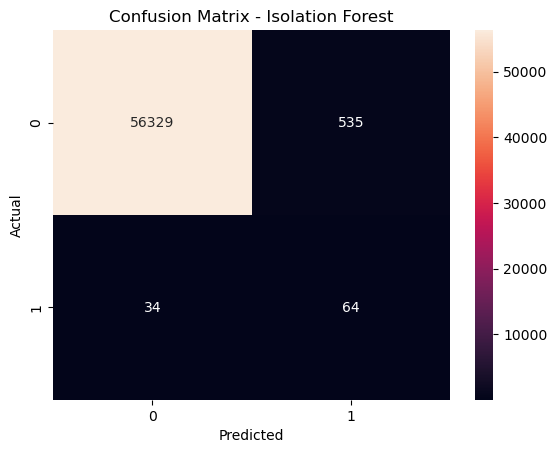

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

cm = confusion_matrix(y_test, preds_if_final)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [83]:
# solation Forest was applied as an unsupervised anomaly detection method. 
#The model was trained on normal transactions only and evaluated on the full dataset. 
#Results indicate that while the model can identify anomalous patterns, performance is sensitive to contamination rate and data imbalance.

In [85]:
for c in [0.001,0.002,0.005]:
    model = IsolationForest(contamination=c, random_state=42)
    model.fit(X_train)
    preds = model.predict(X_test)
    preds = [1 if x == -1 else 0 for x in preds]
    print(f"\nContamination:{c}")
    print(classification_report(y_test, preds))




Contamination:0.001
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.23      0.28        98

    accuracy                           1.00     56962
   macro avg       0.68      0.62      0.64     56962
weighted avg       1.00      1.00      1.00     56962


Contamination:0.002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.29      0.35      0.31        98

    accuracy                           1.00     56962
   macro avg       0.64      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962


Contamination:0.005
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.15      0.44      0.22        98

    accuracy                           0.99     56962
   macro avg       0.57      0.72      0.61     56962
weighted av

In [87]:
                                               # One-Class SVM

In [89]:
# One-Class SVM is:
	#Sensitive to scale
	#Slower than Isolation Forest

In [91]:
# Scale Data

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
from sklearn.svm import OneClassSVM
model_svm = OneClassSVM(
    kernel = 'rbf',
    gamma = 'scale',
    nu=0.01 # similar to contamination
)
model_svm.fit(X_train_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,nu,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [96]:
# predict

In [97]:
preds_svm_final = model_svm.predict(X_test_scaled)
# convert labels
preds_svm_final = [1 if x ==-1 else 0 for x in preds_svm_final]

In [ ]:
# Evalate

In [98]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds_svm_final))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.08      0.56      0.13        98

    accuracy                           0.99     56962
   macro avg       0.54      0.77      0.56     56962
weighted avg       1.00      0.99      0.99     56962



In [103]:
# Confusion Matrix

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


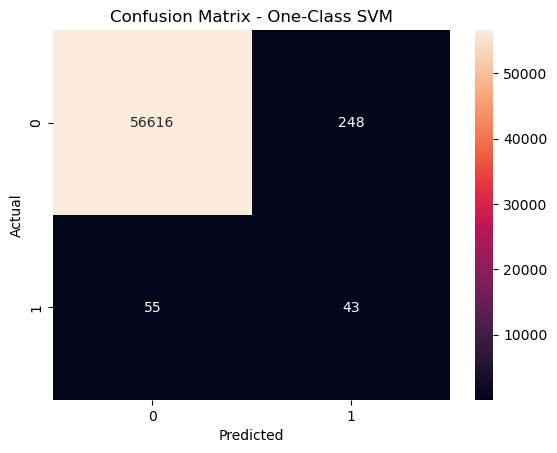

In [107]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - One-Class SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [109]:
                                                   # Autoencoder

In [111]:
#Concept (simple)

#Train model to reconstruct normal transactions
#Fraud → high reconstruction error
#Use error threshold → classify anomalies

In [113]:
# Autoencoder is sensitive to Scaling, Overfitting

In [115]:
# Scale Date

In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [119]:
# Build Autoencoder

In [121]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [123]:
from tensorflow.keras import layers, Input
import tensorflow as tf

input_dim = X_train_scaled.shape[1]

model = tf.keras.Sequential([
    Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

In [125]:
# Train Model(Only normal data)

In [127]:
history = model.fit(
    X_train_scaled, X_train_scaled,
    epochs=20,
    batch_size = 256,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 405us/step - loss: 0.7702 - val_loss: 0.6264
Epoch 2/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 0.6071 - val_loss: 0.5546
Epoch 3/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 0.5527 - val_loss: 0.5193
Epoch 4/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - loss: 0.5228 - val_loss: 0.4995
Epoch 5/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - loss: 0.5080 - val_loss: 0.4907
Epoch 6/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - loss: 0.5002 - val_loss: 0.4844
Epoch 7/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 0.4950 - val_loss: 0.4793
Epoch 8/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 0.4910 - val_loss: 0.4755
Epoch 9/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 0.4875 - val_loss: 0.4762
Epoch 10/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - loss: 0.4853 - val_loss: 0.4718
Epoch 11/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - loss: 0.4834 - val_loss: 0.4691
Epoch 12/20
802/802 ━━━━━━━━━━

In [129]:
# Reconstruction Error

In [131]:
reconstructions = model.predict(X_test_scaled)

import numpy as np
mse = np.mean((X_test_scaled - reconstructions) ** 2, axis=1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 172us/step


In [133]:
# Set Threshold

In [135]:
threshold = np.percentile(mse, 97)

In [137]:
# Predict Fraud

In [139]:
preds_ae_final = [1 if x > threshold else 0 for x in mse]

In [141]:
# Evaluate

In [143]:
from sklearn.metrics import classification_report
print (classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.15      0.44      0.22        98

    accuracy                           0.99     56962
   macro avg       0.57      0.72      0.61     56962
weighted avg       1.00      0.99      1.00     56962



In [145]:
# Confusion Matrix

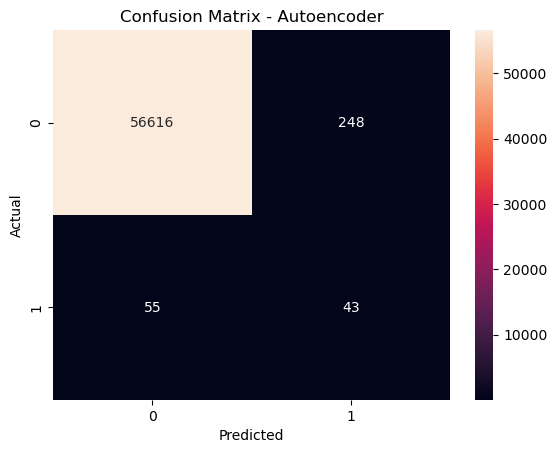

In [147]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Autoencoder")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [149]:
# An autoencoder-based anomaly detection model was implemented using reconstruction error as the anomaly score. 
#The model demonstrated improved capability in capturing non-linear relationships compared to traditional methods, 
#though performance depends heavily on threshold selection.


In [151]:
# try different thresholds

In [153]:
for p in [95, 97, 99]:
    threshold = np.percentile(mse, p)
    preds = [1 if x > threshold else 0 for x in mse]

    print(f"\nThreshold percentile: {p}")
    print(classification_report(y_test, preds))


Threshold percentile: 95
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.73      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.84      0.51     56962
weighted avg       1.00      0.95      0.97     56962


Threshold percentile: 97
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.62      0.07        98

    accuracy                           0.97     56962
   macro avg       0.52      0.80      0.53     56962
weighted avg       1.00      0.97      0.98     56962


Threshold percentile: 99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.06      0.34      0.10        98

    accuracy                           0.99     56962
   macro avg       0.53      0.66      0.55     56

In [155]:
                                 # XGBoost(Supervised Baseline)

In [157]:
#Why XGBoost?

# One of the best-performing models in fraud detection
# Handles imbalanced data well
# Gives you a strong benchmark against anomaly detection

In [159]:
# IMPORTANT DIFFERENCE 
# PREVIOUS MODELS - Unsupervised (no labels)
# GXBoost : Supervised ( uses fraud labels)

In [161]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [163]:
# Handle Imbalance

In [165]:
scale_pos_weight = len(y_train_full[y_train_full == 0]) / len(y_train_full[y_train_full == 1])

In [167]:
# Train XGBoost

In [169]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train_full, y_train_full)

/opt/anaconda3/envs/fraud_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:21:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [171]:
# Predict 

In [173]:
preds_xgb_final = model.predict(X_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step


In [ ]:
# Evaluate

In [175]:
preds_xgb_final = (model_xgb.predict_proba(X_test)[:,1] > 0.5).astype(int)

In [177]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds_xgb_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.87      0.64        98

    accuracy                           1.00     56962
   macro avg       0.76      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [179]:
print(len(y_test))
print(len(preds_if_final))
print(len(preds_svm_final))
print(len(preds_ae_final))
print(len(preds_xgb_final))

56962
56962
56962
56962
56962


In [ ]:
# Confusion Matrix

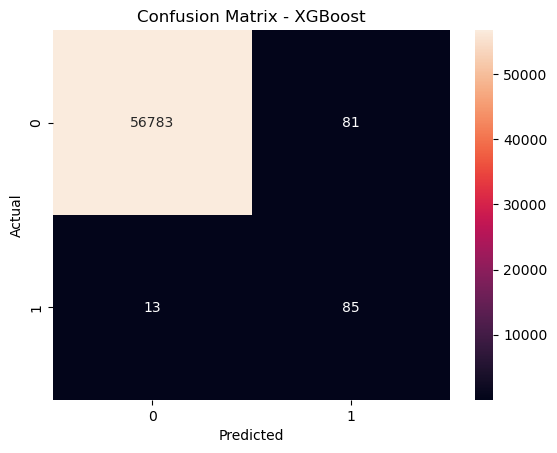

In [181]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds_xgb_final)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [183]:
# XGBoost, a supervised learning model, outperformed unsupervised anomaly detection methods by leveraging labeled data and handling 
# class imbalance through weighted learning. 
#This highlights the advantage of supervised approaches when labeled fraud data is available.

In [185]:
# Create comparison table

In [187]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

In [189]:
# Helper function

In [191]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

In [ ]:
# Adding my model

In [193]:
results = []

results.append(evaluate_model("Isolation Forest", y_test, preds_if_final))
results.append(evaluate_model("One-Class SVM", y_test, preds_svm_final))
results.append(evaluate_model("Autoencoder", y_test, preds_ae_final))
results.append(evaluate_model("XGBoost", y_test, preds_xgb_final))

df_results = pd.DataFrame(results)
df_results

,Model,Precision,Recall,F1-Score
0,Isolation Forest,0.106845,0.653061,0.183644
1,One-Class SVM,0.075446,0.561224,0.133011
2,Autoencoder,0.035693,0.622449,0.067515
3,XGBoost,0.512048,0.867347,0.643939


In [195]:
preds_if_final = model_if.predict(X_test)
print(len(preds_if_final))

56962


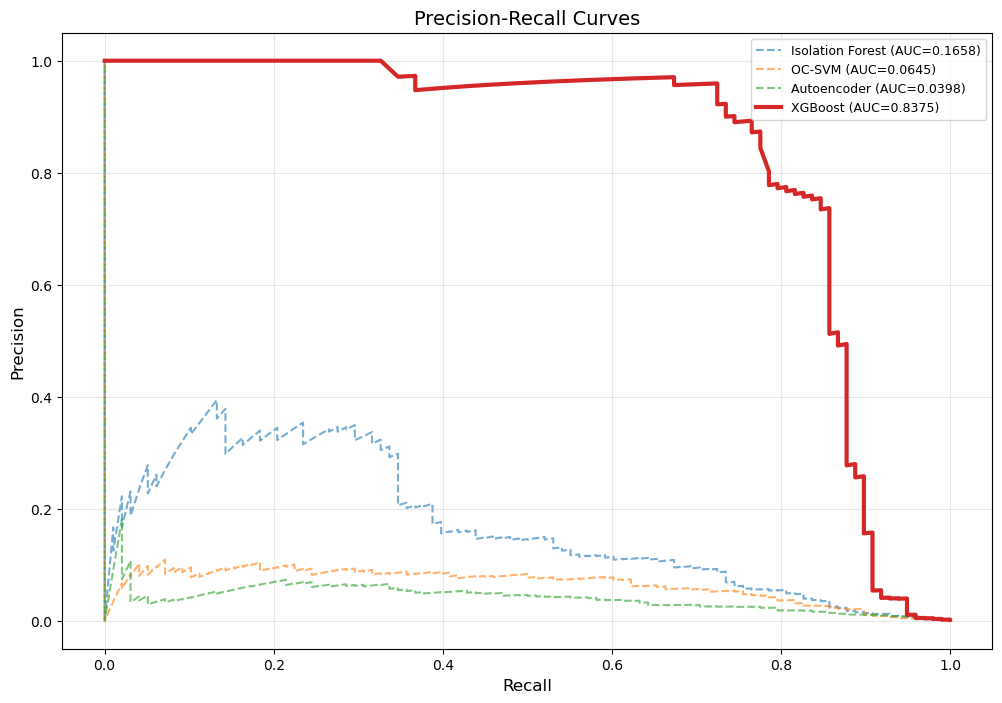

In [199]:
plt.figure(figsize=(12, 8))

# Other models (faded + thinner)
p, r, _ = precision_recall_curve(y_test, -model_if.decision_function(X_test))
plt.plot(r, p, linestyle='--', alpha=0.6, label=f"Isolation Forest (AUC={auc(r,p):.4f})")

p, r, _ = precision_recall_curve(y_test, -model_svm.decision_function(X_test_scaled))
plt.plot(r, p, linestyle='--', alpha=0.6, label=f"OC-SVM (AUC={auc(r,p):.4f})")

p, r, _ = precision_recall_curve(y_test, mse)
plt.plot(r, p, linestyle='--', alpha=0.6, label=f"Autoencoder (AUC={auc(r,p):.4f})")

# ⭐ XGBoost (highlighted)
p, r, _ = precision_recall_curve(y_test, model_xgb.predict_proba(X_test)[:,1])
plt.plot(
    r, p,
    linewidth=3,
    label=f"XGBoost (AUC={auc(r,p):.4f})"
)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves", fontsize=14)

plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.savefig("pr_curve.png", dpi=100, bbox_inches='tight')

plt.show()


In [205]:
# End of the project.
# Thank you
# Imtiaz Islam
